In [3]:
import sys
sys.path.append('../')
import os
import torch
from dotenv import load_dotenv
import LLMP as L

# Clear CUDA cache if using GPU
torch.cuda.empty_cache()

# Load environment variables from the .env file
load_dotenv()

# Create instances of the Gemini models
gpt4vision = L.GPTModel("gpt-4-vision-preview")
gpt4o = L.GPTModel("gpt-4o")
gemini1 = L.GeminiProVision()  
gemini2 = L.Gemini1_5Flash() 

# Add them to a dictionary for easy access
model_instances = {
    "gpt4o": gpt4o,
    "gpt4vision": gpt4vision,
    "LLaVA": L.LLaVA(),  
    "CustomLLaVA": L.CustomLLaVA(),  
    "GeminiProVision": gemini1,  
    "Gemini1_5Flash": gemini2
}

query = "What do you see? If you see a line, can you estimate the length of it in pixels? (The image itself is 100 by 100 pixels) Please respond with a possible range not larger than 10 pixels and report just the numbers."
images = [L.GPImage.figure1('length') for i in range(10)]

# Run the evaluator
result1 = L.Evaluator.run(images, query, model_instances)

print (result1)

Initializing GPTModel with model_name: gpt-4-vision-preview
Initializing GPTModel with model_name: gpt-4o


/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
Loading checkpoint shards: 100%|██████████████████| 2/2 [00:05<00:00,  2.76s/it]
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:389: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/

{'gt': [51, 35, 55, 28, 35, 30, 7, 15, 19, 9], 'gpt4o': {'raw_answers': ['25-35', '20-30', '20-30', '30-40', '21-30', '20-30', '9-19', '10-20', '8-10', '7-8'], 'parsed_answers': [[25.0, 35.0], [20.0, 30.0], [20.0, 30.0], [30.0, 40.0], [21.0, 30.0], [20.0, 30.0], [9.0, 19.0], [10.0, 20.0], [8.0, 10.0], [7.0, 8.0]], 'mean': 21.1, 'std': 8.69712596206356, 'mse': 175.65, 'mlae': 9.980318117957545, 'times': [5696.299076080322, 5631.64758682251, 5625.702142715454, 5610.458135604858, 7436.013221740723, 5678.962230682373, 5582.25679397583, 5796.3707447052, 5853.9087772369385, 6442.023992538452], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['70-80', '70-80', '70-80', '25-35', '70-80', '70-80', '25-35', '30-40', '20-30', '25-35'], 'parsed_answers': [[70.0, 80.0], [70.0, 80.0], [70.0, 80.0], [25.0, 35.0], [70.0, 80.0], [70.0, 80.0], [25.0, 35.0], [30.0, 40.0], [20.0, 30.0], [25.0, 35.0]], 'mean': 52.5, 'std': 22.610838109190027, 'mse': 761.1, 'mlae': 11.234892257757775, 'times': [5852

In [4]:
query = "What do you see? If you see a line, can you estimate the length of it in pixels? (The image itself is 100 by 100 pixels) Please respond with a possible range not larger than 10 pixels and report just the numbers."
images = [L.GPImage.figure1('length') for i in range(10)]

# Run the evaluator
result2 = L.Evaluator.run(images, query, model_instances)

print (result2)

/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
Loading checkpoint shards: 100%|██████████████████| 2/2 [00:05<00:00,  2.80s/it]
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:389: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/

{'gt': [25, 41, 8, 14, 34, 33, 6, 40, 9, 13], 'gpt4o': {'raw_answers': ['15-25', '20-30', '15-20', '3-6', '10-20', '8-17', '5-10', '30, 40', '9-15', '8-10'], 'parsed_answers': [[15.0, 25.0], [20.0, 30.0], [15.0, 20.0], [3.0, 6.0], [10.0, 20.0], [8.0, 17.0], [5.0, 10.0], [30.0, 40.0], [9.0, 15.0], [8.0, 10.0]], 'mean': 15.8, 'std': 8.61742420912421, 'mse': 129.5, 'mlae': 9.86128080358871, 'times': [5868.429660797119, 5775.050640106201, 5893.985271453857, 7851.382493972778, 5676.456451416016, 5727.9980182647705, 5667.142629623413, 5673.719644546509, 5694.149017333984, 5787.923812866211], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['30-40', '70-80', '30-40', '20-30', '70-80', '50-60', '7-15', '70-80', '13-23', '20-30'], 'parsed_answers': [[30.0, 40.0], [70.0, 80.0], [30.0, 40.0], [20.0, 30.0], [70.0, 80.0], [50.0, 60.0], [7.0, 15.0], [70.0, 80.0], [13.0, 23.0], [20.0, 30.0]], 'mean': 42.9, 'std': 23.75057894031217, 'mse': 574.6, 'mlae': 11.008516161589487, 'times': [5903.6965

In [5]:
query = "What do you see? If you see a line, can you estimate the length of it in pixels? (The image itself is 100 by 100 pixels) Please respond with a possible range not larger than 10 pixels and report just the numbers."
images = [L.GPImage.figure1('length') for i in range(10)]

# Run the evaluator
result3 = L.Evaluator.run(images, query, model_instances)

print (result3)

/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
Loading checkpoint shards: 100%|██████████████████| 2/2 [00:05<00:00,  2.77s/it]
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:389: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/

{'gt': [17, 60, 32, 42, 19, 15, 44, 16, 54, 56], 'gpt4o': {'raw_answers': ['9-18', '30-40', '40-50', '20-30', '7-16', '20-30', '30-35', '9-18', '40-50 pixels', '40-50'], 'parsed_answers': [[9.0, 18.0], [30.0, 40.0], [40.0, 50.0], [20.0, 30.0], [7.0, 16.0], [20.0, 30.0], [30.0, 35.0], [9.0, 18.0], [40.0, 50.0], [40.0, 50.0]], 'mean': 29.1, 'std': 12.78632081562167, 'mse': 159.2, 'mlae': 10.10345174171609, 'times': [5786.870718002319, 5727.606773376465, 5657.782793045044, 5750.52285194397, 6004.70232963562, 5963.350296020508, 5896.131992340088, 5651.119709014893, 5805.186033248901, 5727.424621582031], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['15-25', '70-80', '70-80', '70-80', '15-25', '20-30', '70-80', '20-30', '70-80', '70-80'], 'parsed_answers': [[15.0, 25.0], [70.0, 80.0], [70.0, 80.0], [70.0, 80.0], [15.0, 25.0], [20.0, 30.0], [70.0, 80.0], [20.0, 30.0], [70.0, 80.0], [70.0, 80.0]], 'mean': 54.0, 'std': 25.768197453450252, 'mse': 511.7, 'mlae': 10.853407031505254, 't

+-----------------+--------------+--------------+--------------+---------------+---------------+---------------+
|      Model      | Result 1 MSE | Result 2 MSE | Result 3 MSE | Result 1 MLAE | Result 2 MLAE | Result 3 MLAE |
+-----------------+--------------+--------------+--------------+---------------+---------------+---------------+
|      gpt4o      |    175.7     |    129.5     |    159.2     |      10.0     |      9.9      |      10.1     |
|    gpt4vision   |    761.1     |    574.6     |    511.7     |      11.2     |      11.0     |      10.9     |
|      LLaVA      |    1515.6    |    2051.7    |    850.7     |      11.5     |      11.6     |      11.3     |
|   CustomLLaVA   |    312.5     |    585.8     |    856.8     |      10.6     |      11.0     |      11.3     |
| GeminiProVision |    2229.6    |    3310.2    |    2331.7    |      12.1     |      12.5     |      12.1     |
|  Gemini1_5Flash |    1042.4    |    765.2     |    1834.5    |      11.3     |      11.1     |

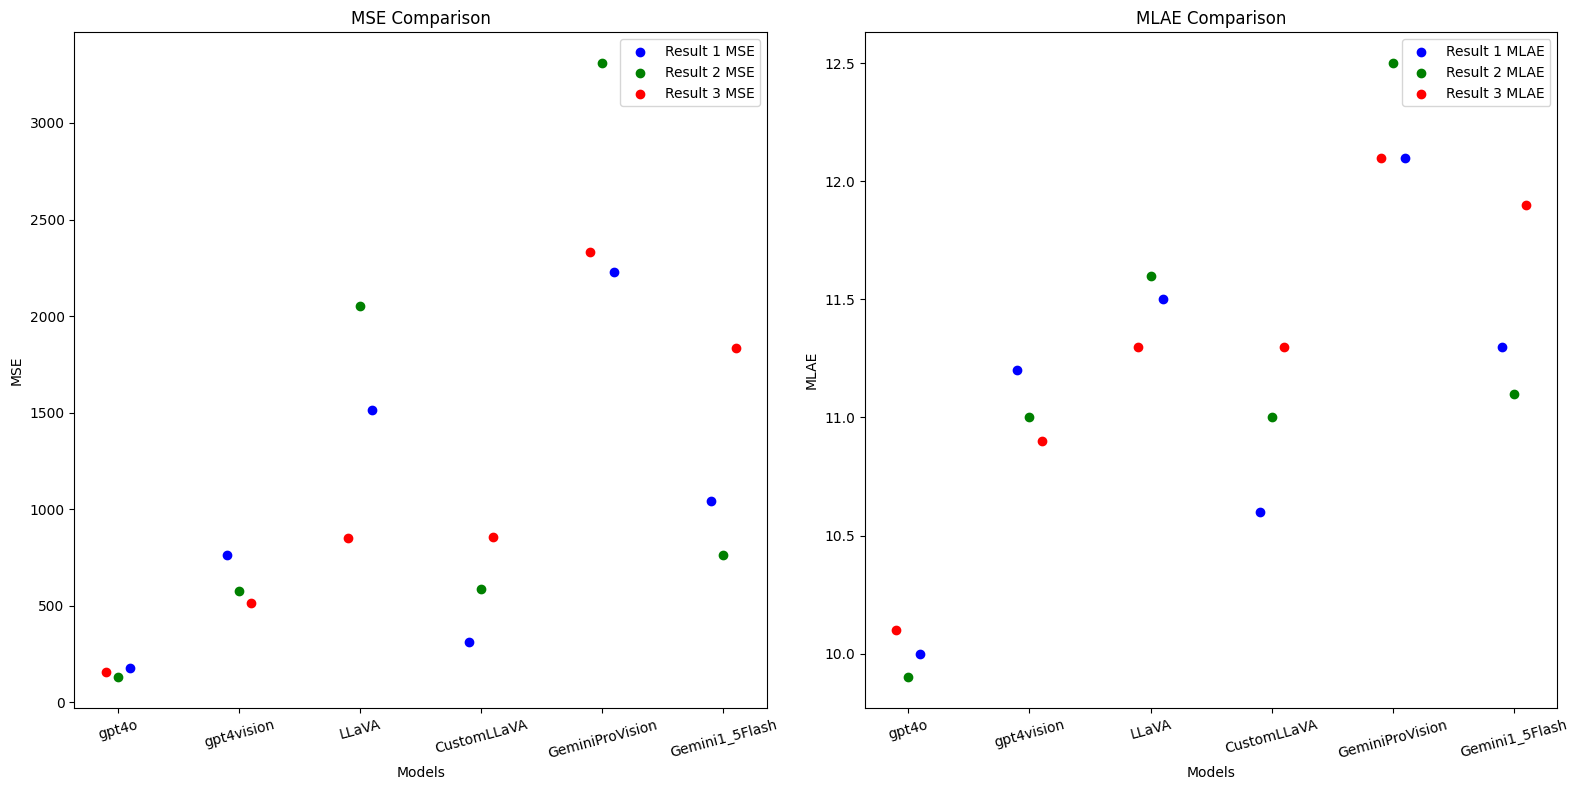

In [1]:
from plot_model_metrics import plot_charts_metrics

result1={'gt': [51, 35, 55, 28, 35, 30, 7, 15, 19, 9], 'gpt4o': {'raw_answers': ['25-35', '20-30', '20-30', '30-40', '21-30', '20-30', '9-19', '10-20', '8-10', '7-8'], 'parsed_answers': [[25.0, 35.0], [20.0, 30.0], [20.0, 30.0], [30.0, 40.0], [21.0, 30.0], [20.0, 30.0], [9.0, 19.0], [10.0, 20.0], [8.0, 10.0], [7.0, 8.0]], 'mean': 21.1, 'std': 8.69712596206356, 'mse': 175.65, 'mlae': 9.980318117957545, 'times': [5696.299076080322, 5631.64758682251, 5625.702142715454, 5610.458135604858, 7436.013221740723, 5678.962230682373, 5582.25679397583, 5796.3707447052, 5853.9087772369385, 6442.023992538452], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['70-80', '70-80', '70-80', '25-35', '70-80', '70-80', '25-35', '30-40', '20-30', '25-35'], 'parsed_answers': [[70.0, 80.0], [70.0, 80.0], [70.0, 80.0], [25.0, 35.0], [70.0, 80.0], [70.0, 80.0], [25.0, 35.0], [30.0, 40.0], [20.0, 30.0], [25.0, 35.0]], 'mean': 52.5, 'std': 22.610838109190027, 'mse': 761.1, 'mlae': 11.234892257757775, 'times': [5852.985858917236, 5819.3793296813965, 6029.046297073364, 5674.868106842041, 5898.477077484131, 5773.828744888306, 5685.468912124634, 5823.804140090942, 5842.260837554932, 5820.432424545288], 'forced_repetitions': 0}, 'LLaVA': {'raw_answers': ['Yes, I can estimate the length of the line. It is approximately 100 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 100 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 100 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels.'], 'parsed_answers': [[100.0], [10.0], [100.0], [10.0], [10.0], [10.0], [100.0], [10.0], [10.0], [10.0]], 'mean': 37.0, 'std': 41.24318125460256, 'mse': 1515.6, 'mlae': 11.501899368693211, 'times': [11247.12872505188, 11240.634441375732, 11276.418924331665, 11416.362524032593, 11225.244283676147, 11308.374643325806, 12305.797815322876, 11228.410959243774, 11258.332967758179, 11351.444244384766], 'forced_repetitions': 0}, 'CustomLLaVA': {'raw_answers': ['19', '42', '49', '1', '53', '11', '13', '4', '1', '20'], 'parsed_answers': [[19.0], [42.0], [49.0], [1.0], [53.0], [11.0], [13.0], [4.0], [1.0], [20.0]], 'mean': 21.3, 'std': 18.72458277238775, 'mse': 312.5, 'mlae': 10.598168841844732, 'times': [11942.639589309692, 11604.07304763794, 11627.048969268799, 11714.036703109741, 11562.64615058899, 11850.446462631226, 11781.205177307129, 11404.62589263916, 11440.234899520874, 11835.509061813354], 'forced_repetitions': 0}, 'GeminiProVision': {'raw_answers': ['15 25 \n', '60 70 \n', '90 100 \n', '70 80 \n', '60 70 \n', '70 80 \n', '60 70 \n', '70 80 \n', '45 55 \n', '80 90 \n'], 'parsed_answers': [[15.0, 25.0], [60.0, 70.0], [90.0, 100.0], [70.0, 80.0], [60.0, 70.0], [70.0, 80.0], [60.0, 70.0], [70.0, 80.0], [45.0, 55.0], [80.0, 90.0]], 'mean': 67.0, 'std': 19.519221295943137, 'mse': 2229.6, 'mlae': 12.129323270151282, 'times': [5793.960809707642, 5705.7178020477295, 5719.5634841918945, 5613.70062828064, 5677.586078643799, 5612.425804138184, 5625.72717666626, 5605.103492736816, 6025.707006454468, 5656.187295913696], 'forced_repetitions': 0}, 'Gemini1_5Flash': {'raw_answers': ['0-10 \n', '40-50 \n', '80-90 \n', '80-90 \n', '0-10 \n', '0-10 \n', '1-10 \n', '60-70 \n', '10-20 \n', '0-10 \n'], 'parsed_answers': [[0.0, 10.0], [40.0, 50.0], [80.0, 90.0], [80.0, 90.0], [0.0, 10.0], [0.0, 10.0], [1.0, 10.0], [60.0, 70.0], [10.0, 20.0], [0.0, 10.0]], 'mean': 32.05, 'std': 32.837821182289176, 'mse': 1042.425, 'mlae': 11.330426748997999, 'times': [5314.599275588989, 5374.516487121582, 5354.270219802856, 5380.054712295532, 5288.618803024292, 5283.870458602905, 5431.1535358428955, 5385.860204696655, 5385.853290557861, 5332.564353942871], 'forced_repetitions': 0}}
result2={'gt': [25, 41, 8, 14, 34, 33, 6, 40, 9, 13], 'gpt4o': {'raw_answers': ['15-25', '20-30', '15-20', '3-6', '10-20', '8-17', '5-10', '30, 40', '9-15', '8-10'], 'parsed_answers': [[15.0, 25.0], [20.0, 30.0], [15.0, 20.0], [3.0, 6.0], [10.0, 20.0], [8.0, 17.0], [5.0, 10.0], [30.0, 40.0], [9.0, 15.0], [8.0, 10.0]], 'mean': 15.8, 'std': 8.61742420912421, 'mse': 129.5, 'mlae': 9.86128080358871, 'times': [5868.429660797119, 5775.050640106201, 5893.985271453857, 7851.382493972778, 5676.456451416016, 5727.9980182647705, 5667.142629623413, 5673.719644546509, 5694.149017333984, 5787.923812866211], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['30-40', '70-80', '30-40', '20-30', '70-80', '50-60', '7-15', '70-80', '13-23', '20-30'], 'parsed_answers': [[30.0, 40.0], [70.0, 80.0], [30.0, 40.0], [20.0, 30.0], [70.0, 80.0], [50.0, 60.0], [7.0, 15.0], [70.0, 80.0], [13.0, 23.0], [20.0, 30.0]], 'mean': 42.9, 'std': 23.75057894031217, 'mse': 574.6, 'mlae': 11.008516161589487, 'times': [5903.696537017822, 5892.554759979248, 5830.578088760376, 5992.339134216309, 5829.44130897522, 5912.376642227173, 5987.934112548828, 5759.084939956665, 6037.73832321167, 5812.508821487427], 'forced_repetitions': 0}, 'LLaVA': {'raw_answers': ['Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 100 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 100 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.'], 'parsed_answers': [[10.0], [10.0], [100.0], [10.0], [10.0], [10.0], [100.0], [10.0], [10.0], [10.0]], 'mean': 28.0, 'std': 36.0, 'mse': 2051.7, 'mlae': 11.630324012510892, 'times': [11261.768579483032, 11150.517225265503, 11206.489324569702, 11509.578704833984, 11159.480333328247, 11077.902555465698, 11416.905879974365, 11242.629289627075, 11230.259895324707, 11166.889667510986], 'forced_repetitions': 0}, 'CustomLLaVA': {'raw_answers': ['12', '23', '50', '1', '47', '49', '57', '49', '3', '30'], 'parsed_answers': [[12.0], [23.0], [50.0], [1.0], [47.0], [49.0], [57.0], [49.0], [3.0], [30.0]], 'mean': 32.1, 'std': 20.097014703681737, 'mse': 585.8, 'mlae': 10.951375791324496, 'times': [11417.805194854736, 11578.87315750122, 11582.274675369263, 11668.169021606445, 11430.123805999756, 11477.203130722046, 11682.618141174316, 11459.227561950684, 11465.014934539795, 11718.631505966187], 'forced_repetitions': 0}, 'GeminiProVision': {'raw_answers': ['65 75 \n', '90 100 \n', '85 95 \n', '65 75 \n', '65 75 \n', '80 90 \n', '60 70 \n', '85 95 \n', '60 70 \n', '80 90 \n'], 'parsed_answers': [[65.0, 75.0], [90.0, 100.0], [85.0, 95.0], [65.0, 75.0], [65.0, 75.0], [80.0, 90.0], [60.0, 70.0], [85.0, 95.0], [60.0, 70.0], [80.0, 90.0]], 'mean': 78.5, 'std': 10.965856099730654, 'mse': 3310.2, 'mlae': 12.45638650316427, 'times': [5782.126188278198, 5675.46534538269, 5689.28861618042, 5644.5276737213135, 5640.228509902954, 5656.91614151001, 5598.98829460144, 5694.196939468384, 5856.978178024292, 5670.143604278564], 'forced_repetitions': 0}, 'Gemini1_5Flash': {'raw_answers': ['0-10 \n', '0-10 \n', '40-50 \n', '5-15 \n', '5-15 \n', '80-90 \n', '0-10 \n', '0-10 \n', '5-15 \n', '0-10 \n'], 'parsed_answers': [[0.0, 10.0], [0.0, 10.0], [40.0, 50.0], [5.0, 15.0], [5.0, 15.0], [80.0, 90.0], [0.0, 10.0], [0.0, 10.0], [5.0, 15.0], [0.0, 10.0]], 'mean': 18.5, 'std': 25.004999500099974, 'mse': 765.2, 'mlae': 11.090195140632224, 'times': [5282.100439071655, 5330.868244171143, 5307.295799255371, 5382.294416427612, 5370.322465896606, 5328.712463378906, 5307.57474899292, 5288.163661956787, 5582.21960067749, 5281.111001968384], 'forced_repetitions': 0}}
result3={'gt': [17, 60, 32, 42, 19, 15, 44, 16, 54, 56], 'gpt4o': {'raw_answers': ['9-18', '30-40', '40-50', '20-30', '7-16', '20-30', '30-35', '9-18', '40-50 pixels', '40-50'], 'parsed_answers': [[9.0, 18.0], [30.0, 40.0], [40.0, 50.0], [20.0, 30.0], [7.0, 16.0], [20.0, 30.0], [30.0, 35.0], [9.0, 18.0], [40.0, 50.0], [40.0, 50.0]], 'mean': 29.1, 'std': 12.78632081562167, 'mse': 159.2, 'mlae': 10.10345174171609, 'times': [5786.870718002319, 5727.606773376465, 5657.782793045044, 5750.52285194397, 6004.70232963562, 5963.350296020508, 5896.131992340088, 5651.119709014893, 5805.186033248901, 5727.424621582031], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['15-25', '70-80', '70-80', '70-80', '15-25', '20-30', '70-80', '20-30', '70-80', '70-80'], 'parsed_answers': [[15.0, 25.0], [70.0, 80.0], [70.0, 80.0], [70.0, 80.0], [15.0, 25.0], [20.0, 30.0], [70.0, 80.0], [20.0, 30.0], [70.0, 80.0], [70.0, 80.0]], 'mean': 54.0, 'std': 25.768197453450252, 'mse': 511.7, 'mlae': 10.853407031505254, 'times': [5869.901418685913, 5835.6614112854, 5725.757122039795, 5816.796064376831, 5897.51410484314, 5823.247909545898, 5850.412607192993, 5778.454780578613, 5693.503141403198, 5820.747137069702], 'forced_repetitions': 0}, 'LLaVA': {'raw_answers': ['Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 100 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 10 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 100 pixels long.', 'Yes, I can estimate the length of the line. It is approximately 100 pixels long.'], 'parsed_answers': [[10.0], [100.0], [10.0], [10.0], [10.0], [10.0], [10.0], [10.0], [100.0], [100.0]], 'mean': 37.0, 'std': 41.24318125460256, 'mse': 850.7, 'mlae': 11.25863963890211, 'times': [11268.714427947998, 11346.037149429321, 11276.830673217773, 11150.846242904663, 11142.791271209717, 11158.17403793335, 11226.233959197998, 11125.153541564941, 11118.147850036621, 11121.640682220459], 'forced_repetitions': 0}, 'CustomLLaVA': {'raw_answers': ['46', '12', '47', '12', '1', '49', '49', '45', '10', '52'], 'parsed_answers': [[46.0], [12.0], [47.0], [12.0], [1.0], [49.0], [49.0], [45.0], [10.0], [52.0]], 'mean': 32.3, 'std': 19.52459986785901, 'mse': 856.8, 'mlae': 11.321998537261384, 'times': [11757.957935333252, 11503.802299499512, 11447.676420211792, 11687.772750854492, 11510.807752609253, 11580.936908721924, 11496.055126190186, 11669.53182220459, 11534.596681594849, 11515.03038406372], 'forced_repetitions': 0}, 'GeminiProVision': {'raw_answers': ['80 90 \n', '15, 25 \n', '90 100 \n', '90 100 \n', '60 70 \n', '70 80 \n', '5 15 \n', '60 70 \n', '80 90 \n', '60 70 \n'], 'parsed_answers': [[80.0, 90.0], [15.0, 25.0], [90.0, 100.0], [90.0, 100.0], [60.0, 70.0], [70.0, 80.0], [5.0, 15.0], [60.0, 70.0], [80.0, 90.0], [60.0, 70.0]], 'mean': 66.0, 'std': 27.820855486487112, 'mse': 2331.7, 'mlae': 12.145335143850168, 'times': [5832.252264022827, 5649.0583419799805, 5706.850051879883, 5654.998779296875, 5669.261932373047, 5616.522789001465, 5682.098150253296, 5660.348892211914, 5605.7679653167725, 5602.2326946258545], 'forced_repetitions': 0}, 'Gemini1_5Flash': {'raw_answers': ['1-10 \n', '0-10 \n', '5-15 \n', '0-10 \n', '80-90 \n', '0-10 \n', '5-15 \n', '80-90 \n', '30-40 \n', '0-10 \n'], 'parsed_answers': [[1.0, 10.0], [0.0, 10.0], [5.0, 15.0], [0.0, 10.0], [80.0, 90.0], [0.0, 10.0], [5.0, 15.0], [80.0, 90.0], [30.0, 40.0], [0.0, 10.0]], 'mean': 25.05, 'std': 31.19330857732152, 'mse': 1834.525, 'mlae': 11.870798156582575, 'times': [5786.265850067139, 5441.855192184448, 5492.184638977051, 5298.6509799957275, 5358.82568359375, 5275.359869003296, 5280.830144882202, 5335.588455200195, 5332.1168422698975, 5282.837152481079], 'forced_repetitions': 0}}

plot_charts_metrics(result1, result2, result3)